In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Configuração visual dos gráficos
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Carregando os dados e definindo a coluna 'Data' como índice temporal
df = pd.read_csv('mecaniqa_dataset.csv', parse_dates=['Data'], index_col='Data')

# Garantindo que a linha do tempo está ordenada cronologicamente
df = df.sort_index()

print("Visão geral dos dados brutos:")
display(df.head())

Visão geral dos dados brutos:


,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


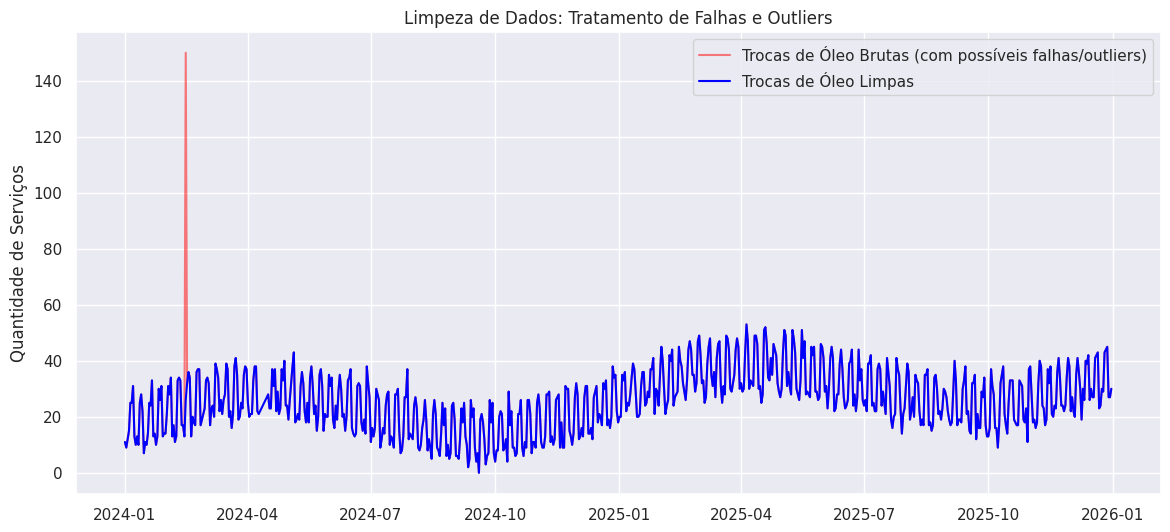

In [12]:

df_limpo = df.copy()

df_limpo = df_limpo.interpolate(method='linear')

colunas_analise = ['Trocas_Oleo', 'Manutencao_Motor']

for col in colunas_analise:
    Q1 = df_limpo[col].quantile(0.25)
    Q3 = df_limpo[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR
    mediana = df_limpo[col].median()


    df_limpo[col] = np.where(
        (df_limpo[col] > limite_superior) | (df_limpo[col] < limite_inferior),
        mediana,
        df_limpo[col]
    )


plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Trocas_Oleo'], label='Trocas de Óleo Brutas (com possíveis falhas/outliers)', color='red', alpha=0.5)
plt.plot(df_limpo.index, df_limpo['Trocas_Oleo'], label='Trocas de Óleo Limpas', color='blue')
plt.title('Limpeza de Dados: Tratamento de Falhas e Outliers')
plt.ylabel('Quantidade de Serviços')
plt.legend()
plt.show()

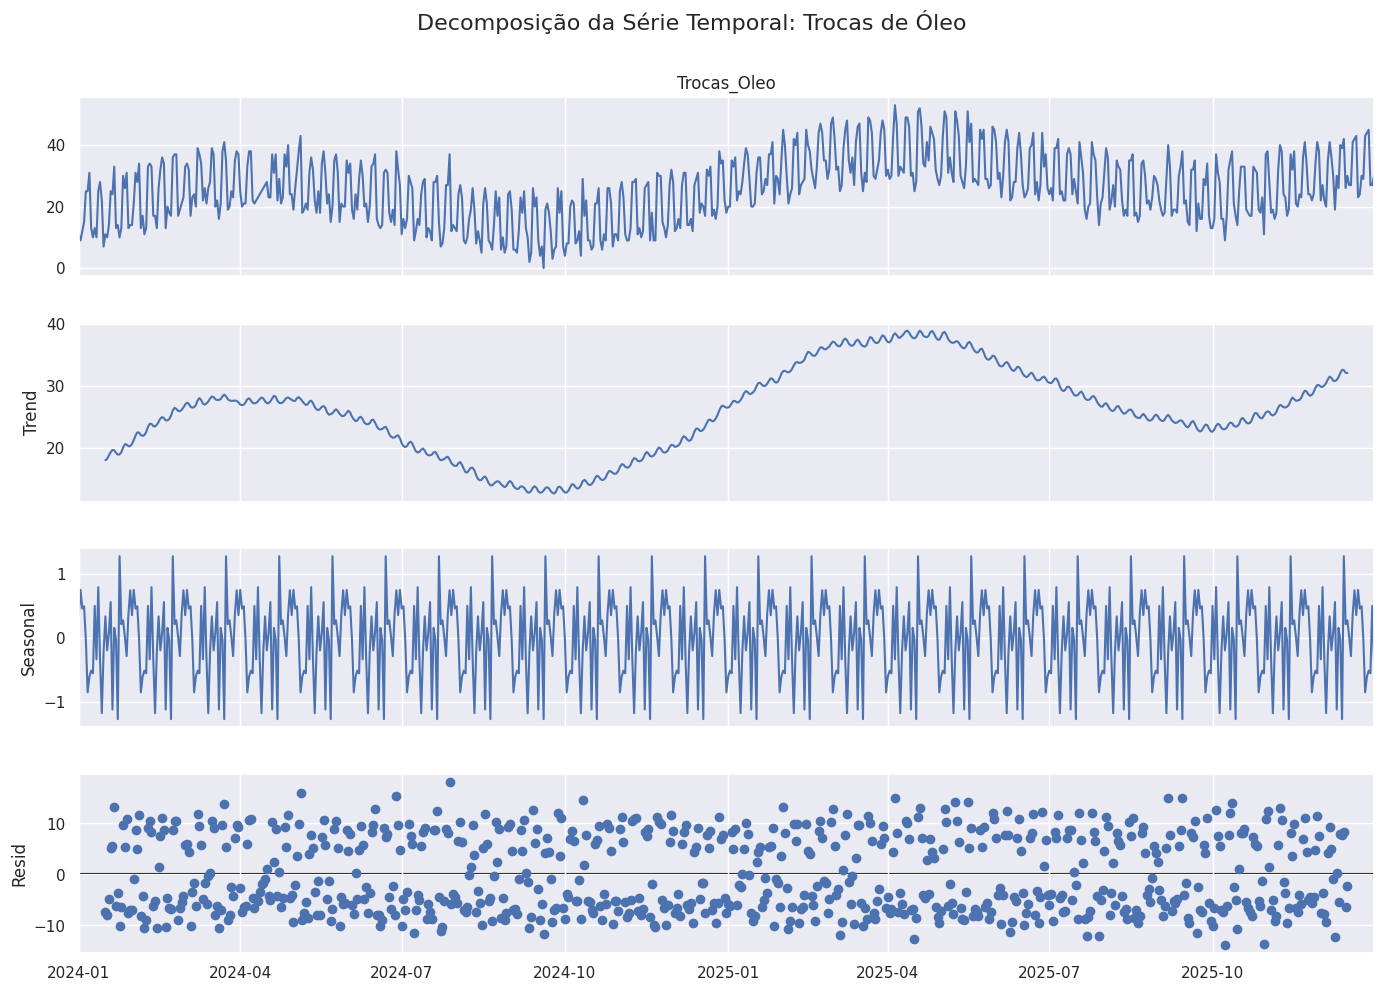

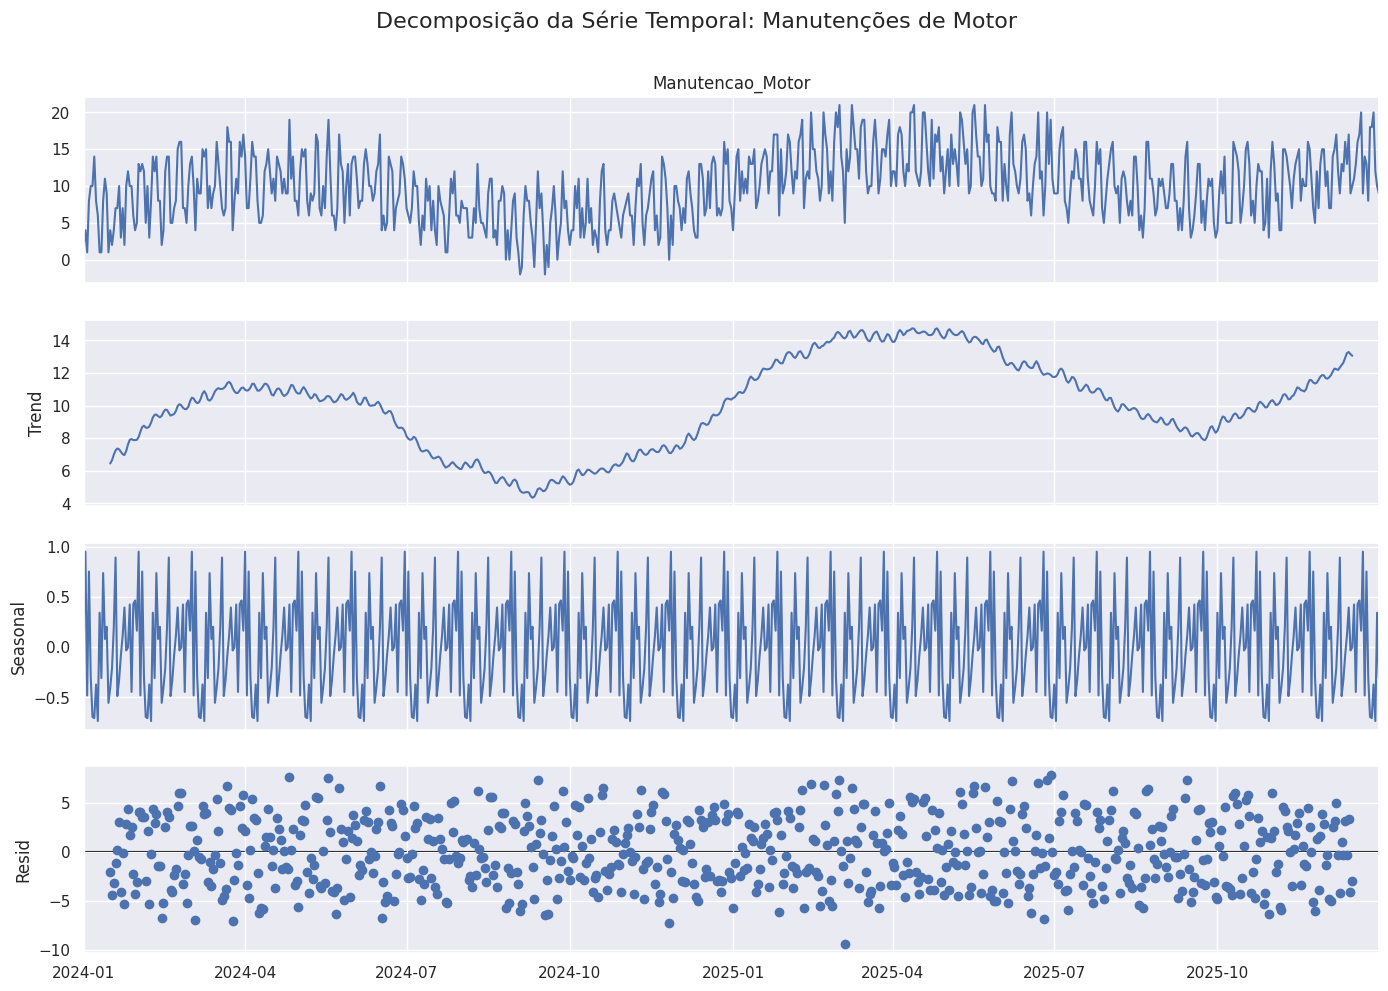

In [13]:

serie_oleo = df_limpo['Trocas_Oleo'].dropna()
serie_motor = df_limpo['Manutencao_Motor'].dropna()


decomposicao_oleo = seasonal_decompose(serie_oleo, model='additive', period=30)
fig1 = decomposicao_oleo.plot()
fig1.set_size_inches(14, 10)
fig1.suptitle('Decomposição da Série Temporal: Trocas de Óleo', fontsize=16, y=1.02)
plt.show()


decomposicao_motor = seasonal_decompose(serie_motor, model='additive', period=30)
fig2 = decomposicao_motor.plot()
fig2.set_size_inches(14, 10)
fig2.suptitle('Decomposição da Série Temporal: Manutenções de Motor', fontsize=16, y=1.02)
plt.show()

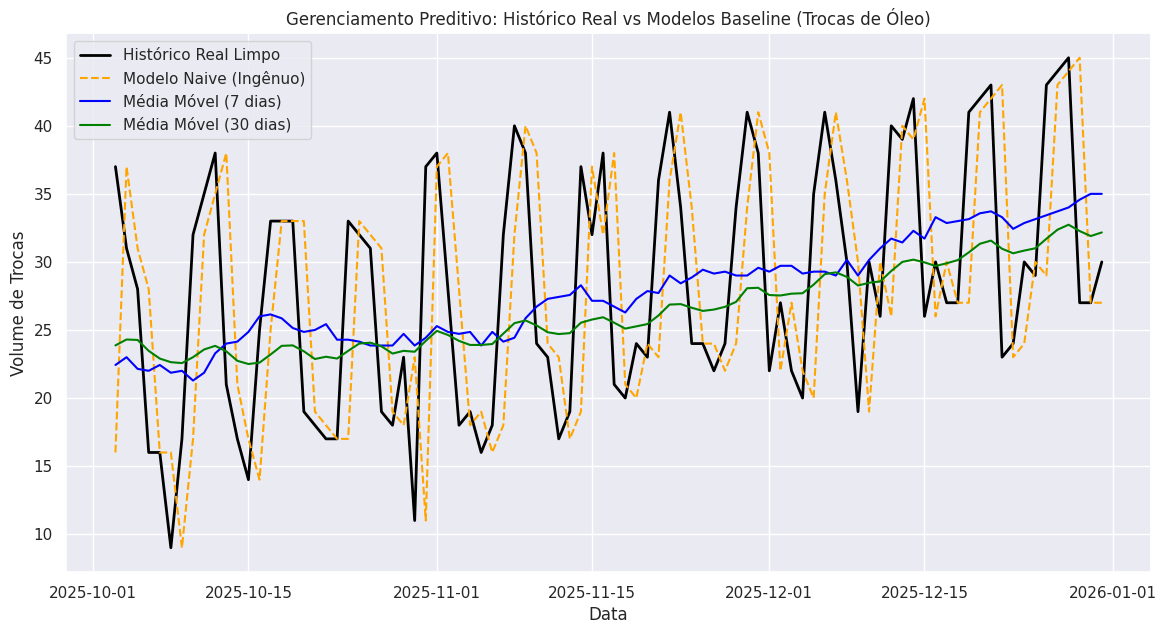

In [15]:

df_prev = df_limpo.copy()


df_prev['naive_oleo'] = df_prev['Trocas_Oleo'].shift(1)


df_prev['mm7_oleo'] = df_prev['Trocas_Oleo'].rolling(window=7).mean()
df_prev['mm30_oleo'] = df_prev['Trocas_Oleo'].rolling(window=30).mean()


df_plot = df_prev.tail(90)


plt.figure(figsize=(14, 7))
plt.plot(df_plot.index, df_plot['Trocas_Oleo'], label='Histórico Real Limpo', color='black', linewidth=2)
plt.plot(df_plot.index, df_plot['naive_oleo'], label='Modelo Naive (Ingênuo)', color='orange', linestyle='--')
plt.plot(df_plot.index, df_plot['mm7_oleo'], label='Média Móvel (7 dias)', color='blue')
plt.plot(df_plot.index, df_plot['mm30_oleo'], label='Média Móvel (30 dias)', color='green')

plt.title('Gerenciamento Preditivo: Histórico Real vs Modelos Baseline (Trocas de Óleo)')
plt.ylabel('Volume de Trocas')
plt.xlabel('Data')
plt.legend()
plt.show()